# **Clustering: Core Idea**

Clustering attempts to answer:

> Can we group data points based on similarity?

**Key Intuition**
- Similar points are close in feature space
- Distance plays a central role

**Example (2D Case)**

Suppose we have:

  - Feature $𝑋_1$
  - Feature $𝑋_2$
	​
  
By plotting:

  - We may observe natural groupings
  - These groupings become clusters

## **Important Observations About Clustering**
- **No True Labels**
  - Clusters are not guaranteed to be correct
  - They are hypotheses, not truths
- **Cluster Labels Are Arbitrary**
  - Output might be:
      - Cluster 0
      - Cluster 1
      - Cluster 2

These have **no inherent meaning.**

**Interpretation is the responsibility of the practitioner.**


## **Ambiguity in Number of Clusters**

Example:

- A dataset may reasonably be grouped into:
  - 2 clusters
  - 3 clusters

There is often **no single correct answer.**

## **High-Dimensional Challenges**
- Real datasets have many features (e.g., 20+)
- Visualization becomes impossible
- Algorithms must infer structure mathematically

## **Assigning New Data Points**

In supervised learning:

  - Predict label directly

In clustering:

  - Assign to **nearest cluster**

However:

  - There is **no guarantee of correctness**
  - Assignment depends on:
      - Distance metric
      - Chosen clustering method

## **Clustering + Supervised Learning**

A powerful workflow:

1. Use clustering to generate pseudo-labels
2. Use those labels as 𝑌
3. Train a supervised model

**Trade-off**
- Labels may be:
  - Useful
  - Misleading

## **Philosophical Perspective**

Clustering raises deeper questions:

- What is a true label?
- Are clusters real or constructed?
- Are we discovering structure or imposing it?

This highlights the **interpretive nature** of unsupervised learning.

<br>

# **K-Means Clustering**

K-Means is one of the simplest and most widely used clustering algorithms.

⚠️ Important:

- K-Means ≠ K-Nearest Neighbors (KNN)
  - K-Means → Unsupervised (clustering)
  - KNN → Supervised (classification/regression)

## **Goal of K-Means**

Partition data into K clusters such that:

- Every point belongs to a cluster
- Each point belongs to **exactly one** cluster







## **Algorithm Steps**
- **Step 1: Choose K**
  - Number of clusters (user-defined)

- **Step 2: Initialize Centroids**
  - Randomly select 𝐾 data points
  - These act as initial cluster centers

- **Step 3: Assign Points**
  - Assign each point to the nearest centroid
  - Distance metric typically:
    - Euclidean distance

- **Step 4: Update Centroids**
  - Compute the mean of points in each cluster
  - This becomes the new centroid

- **Step 5: Repeat**
  - Reassign points
  - Recompute centroids

Until:

  - No points change clusters
  - Centroids stabilize

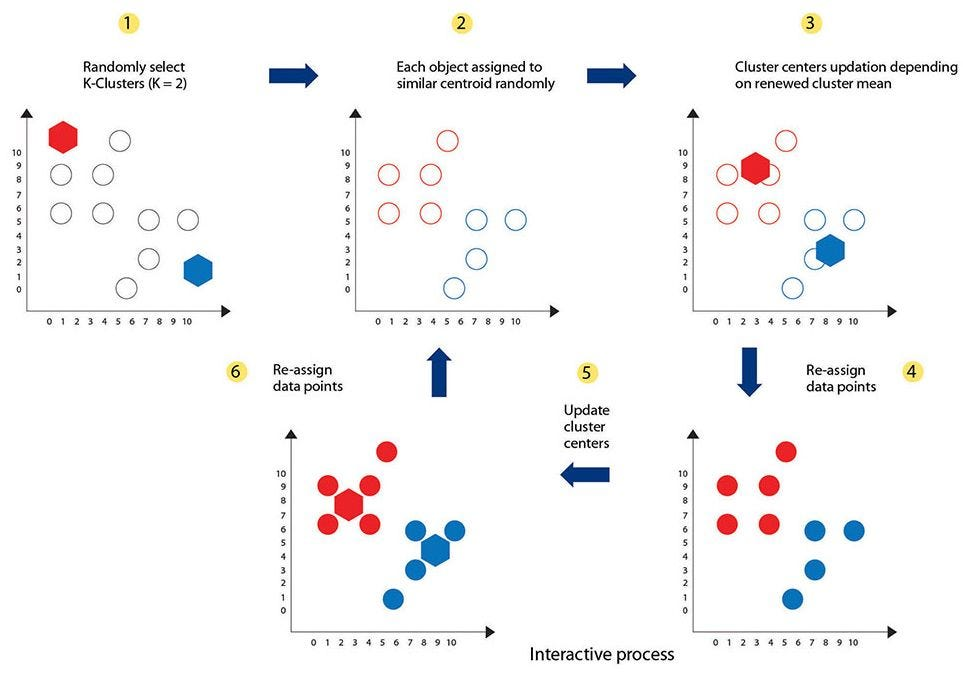

## **Key Intuition**

K-Means is essentially:

> Iteratively refining cluster centers to minimize within-cluster variation

## **Important Considerations**
**Choosing K**
  - Not trivial
  - Often requires experimentation

**Sensitivity to Initialization**
  - Different random starts → different results

**Assumption**
- Clusters are:
  - Spherical
  - Similar in size


Let's work through an example of unsupervised learning - clustering customer data.

## **Goal:**

When working with unsupervised learning methods, its usually important to lay out a general goal. In our case, let's attempt to find reasonable clusters of customers for marketing segmentation and study. What we end up doing with those clusters would depend **heavily** on the domain itself, in this case, marketing.

## **The Data**

LINK: https://archive.ics.uci.edu/ml/datasets/bank+marketing

   This dataset is public available for research. The details are described in [Moro et al., 2011].


      [Moro et al., 2011] S. Moro, R. Laureano and P. Cortez. Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology.
      In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference - ESM'2011, pp. 117-121, Guimarães, Portugal, October, 2011. EUROSIS.

      Available at: [pdf] http://hdl.handle.net/1822/14838
                    [bib] http://www3.dsi.uminho.pt/pcortez/bib/2011-esm-1.txt
     For more information, read [Moro et al., 2011].

The dataset includes information about bank clients

    # bank client data:
    1 - age (numeric)
    2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
    3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
    4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
    5 - default: has credit in default? (categorical: 'no','yes','unknown')
    6 - housing: has housing loan? (categorical: 'no','yes','unknown')
    7 - loan: has personal loan? (categorical: 'no','yes','unknown')
    # related with the last contact of the current campaign:
    8 - contact: contact communication type (categorical: 'cellular','telephone')
    9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
    10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
    11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
    # other attributes:
    12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
    13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
    14 - previous: number of contacts performed before this campaign and for this client (numeric)
    15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
    # social and economic context attributes
    16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
    17 - cons.price.idx: consumer price index - monthly indicator (numeric)
    18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
    19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
    20 - nr.employed: number of employees - quarterly indicator (numeric)
    21 - y - has the client subscribed a term deposit? (binary: 'yes','no')

For our case there is no clear objective for this unsupervided learning process.

## **Exploratory Data Analysis**

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("bank-full.csv")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [19]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'subscribed'],
      dtype='object')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [21]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


### **Continuous Feature Analysis**

<Axes: xlabel='age', ylabel='Count'>

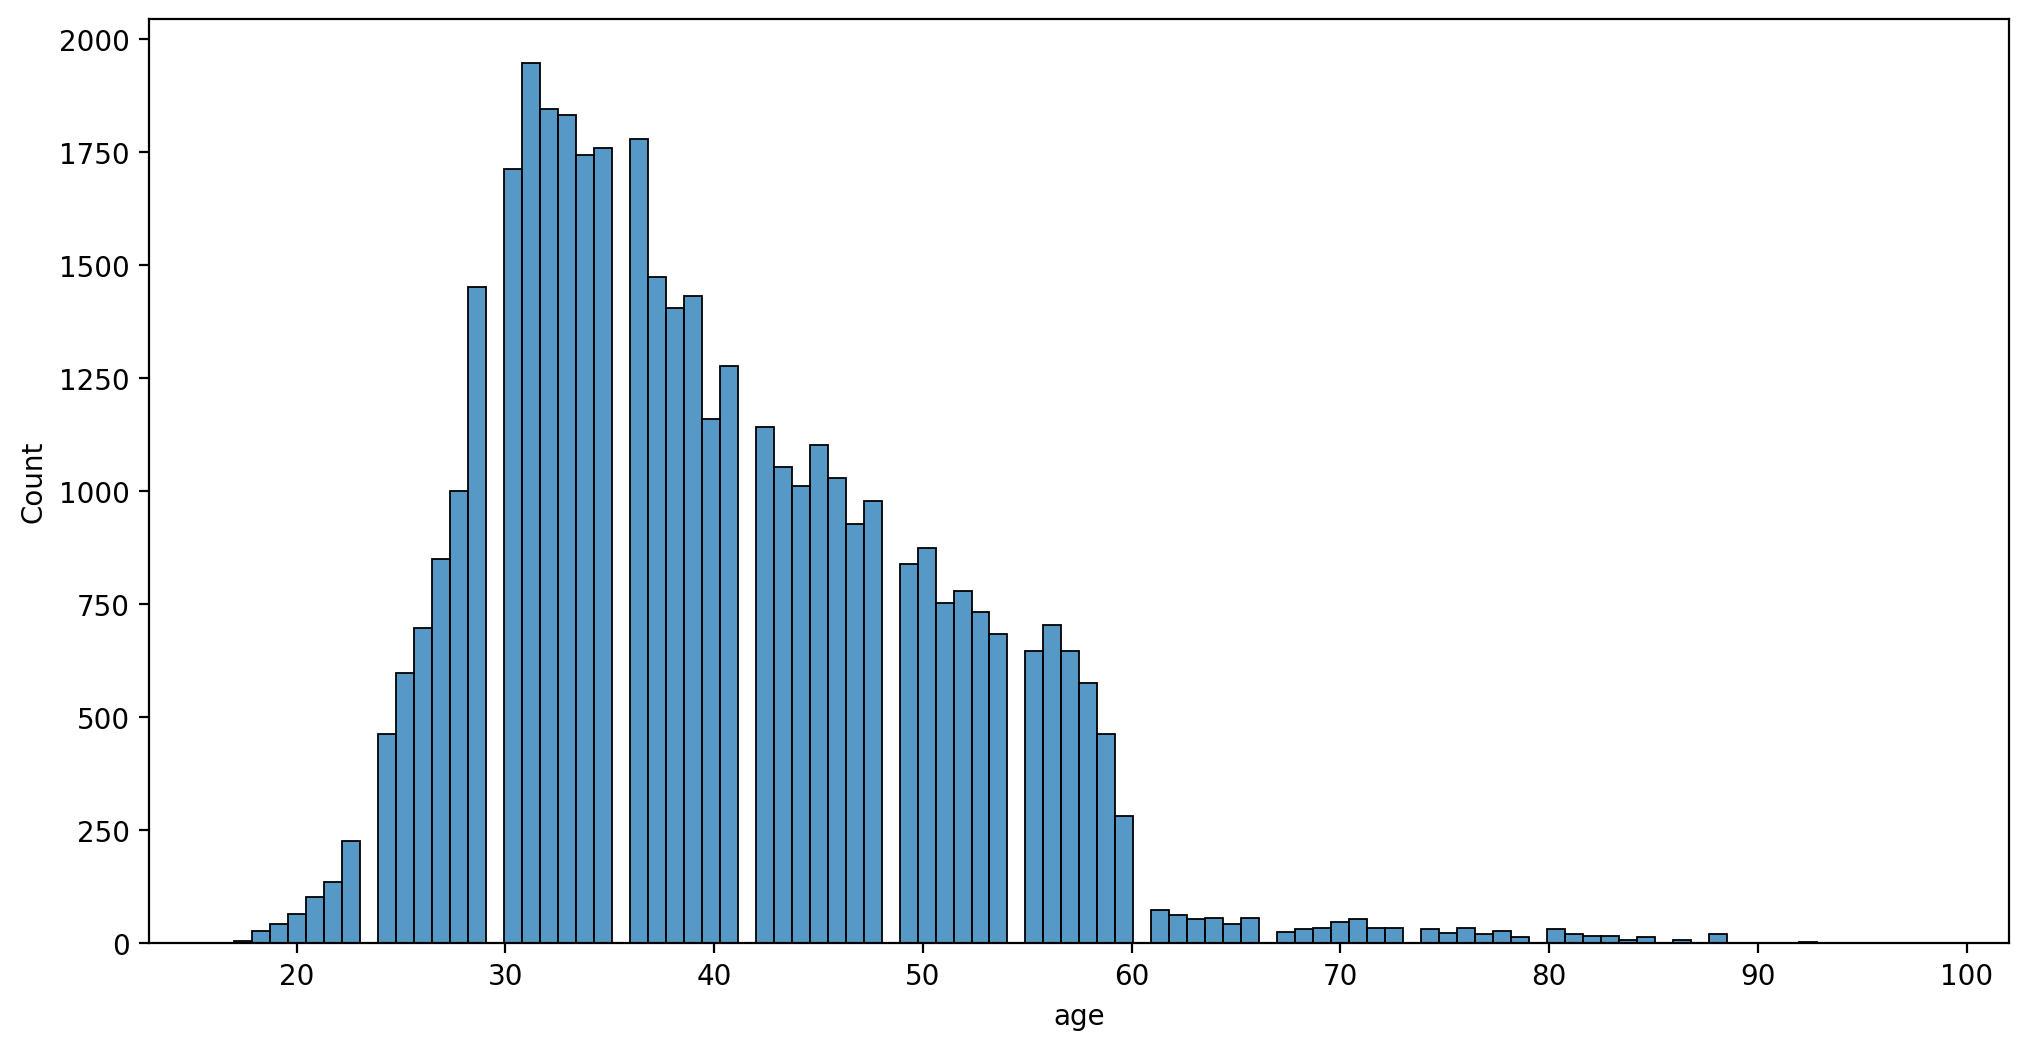

In [22]:
plt.figure(figsize=(12,6),dpi=200)
sns.histplot(data=df,x='age')

# can always change the bin size e.g. bins = 30 to get the general trend

<Axes: xlabel='age', ylabel='Count'>

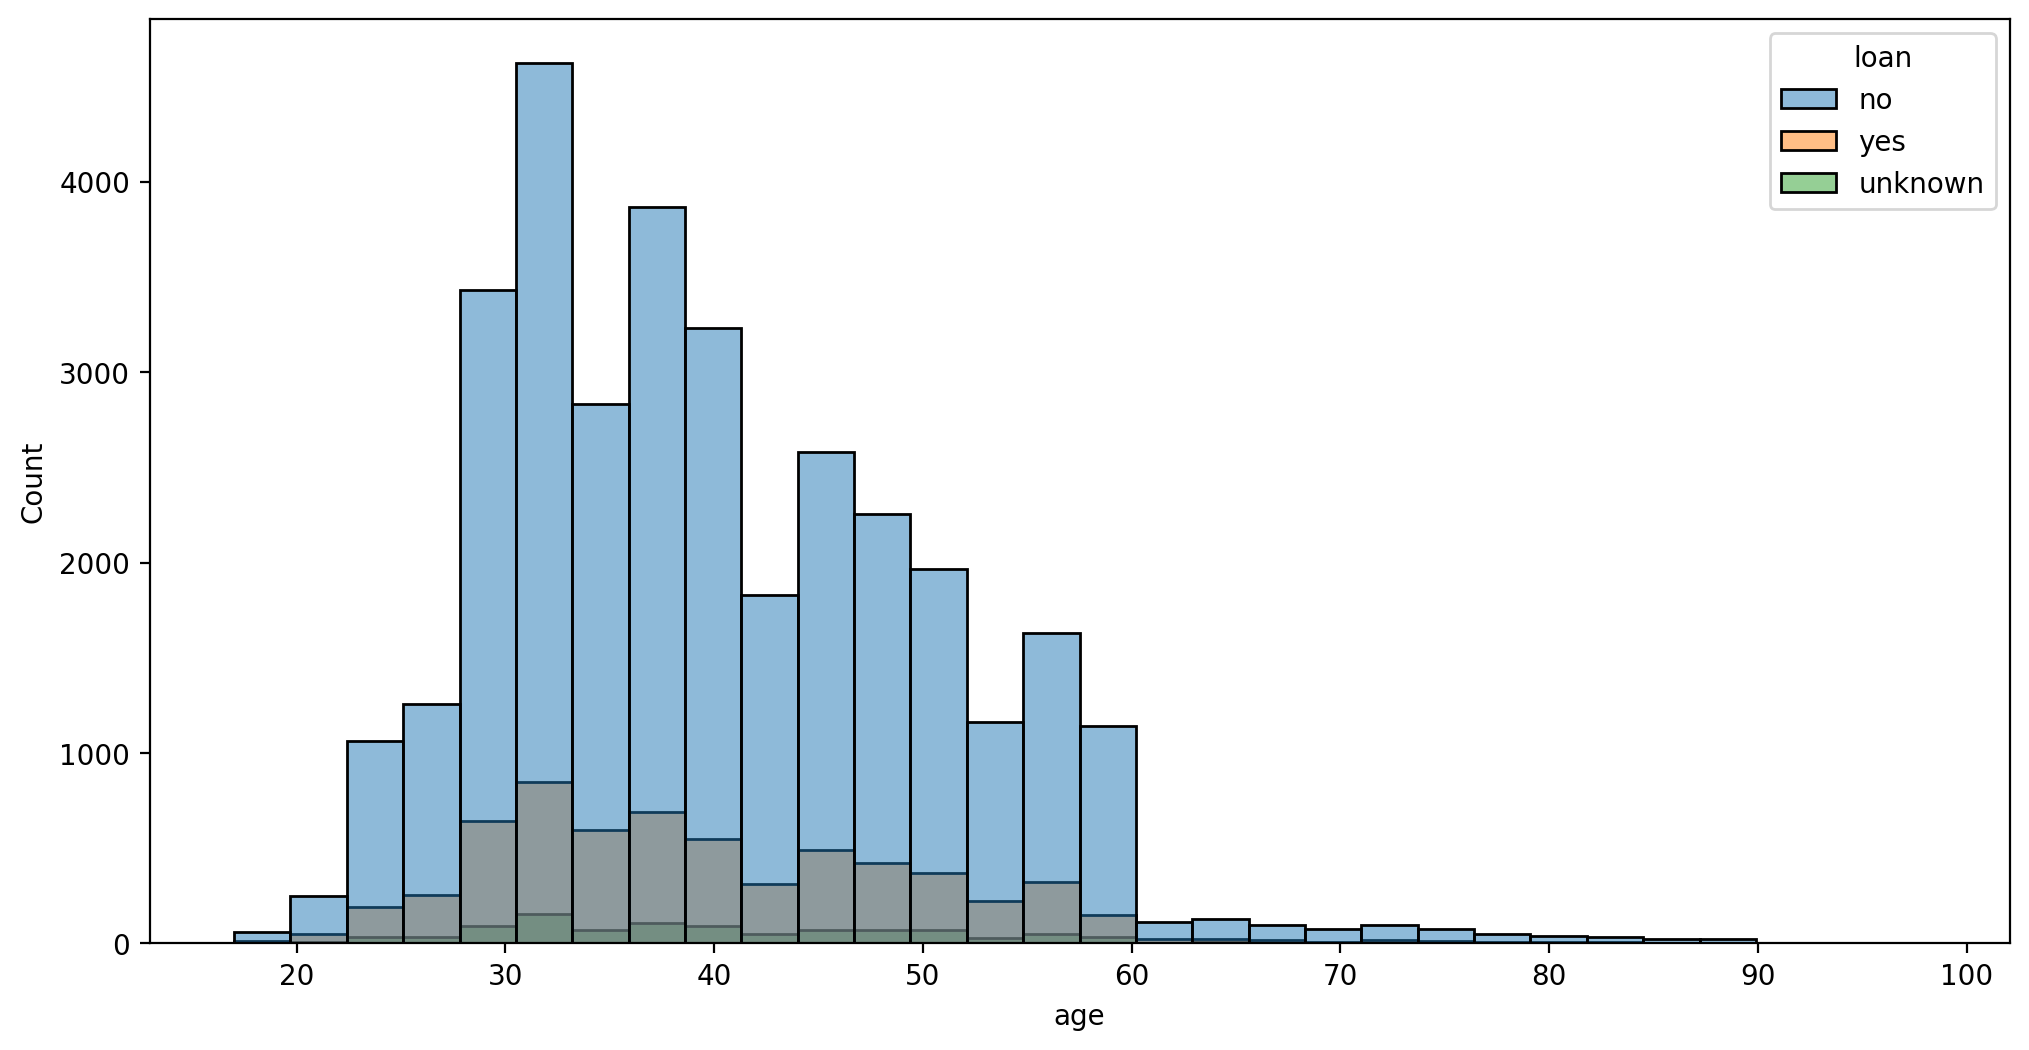

In [25]:
plt.figure(figsize=(12,6),dpi=200)
sns.histplot(data=df,x='age',hue='loan', bins=30)

<Axes: xlabel='pdays', ylabel='Count'>

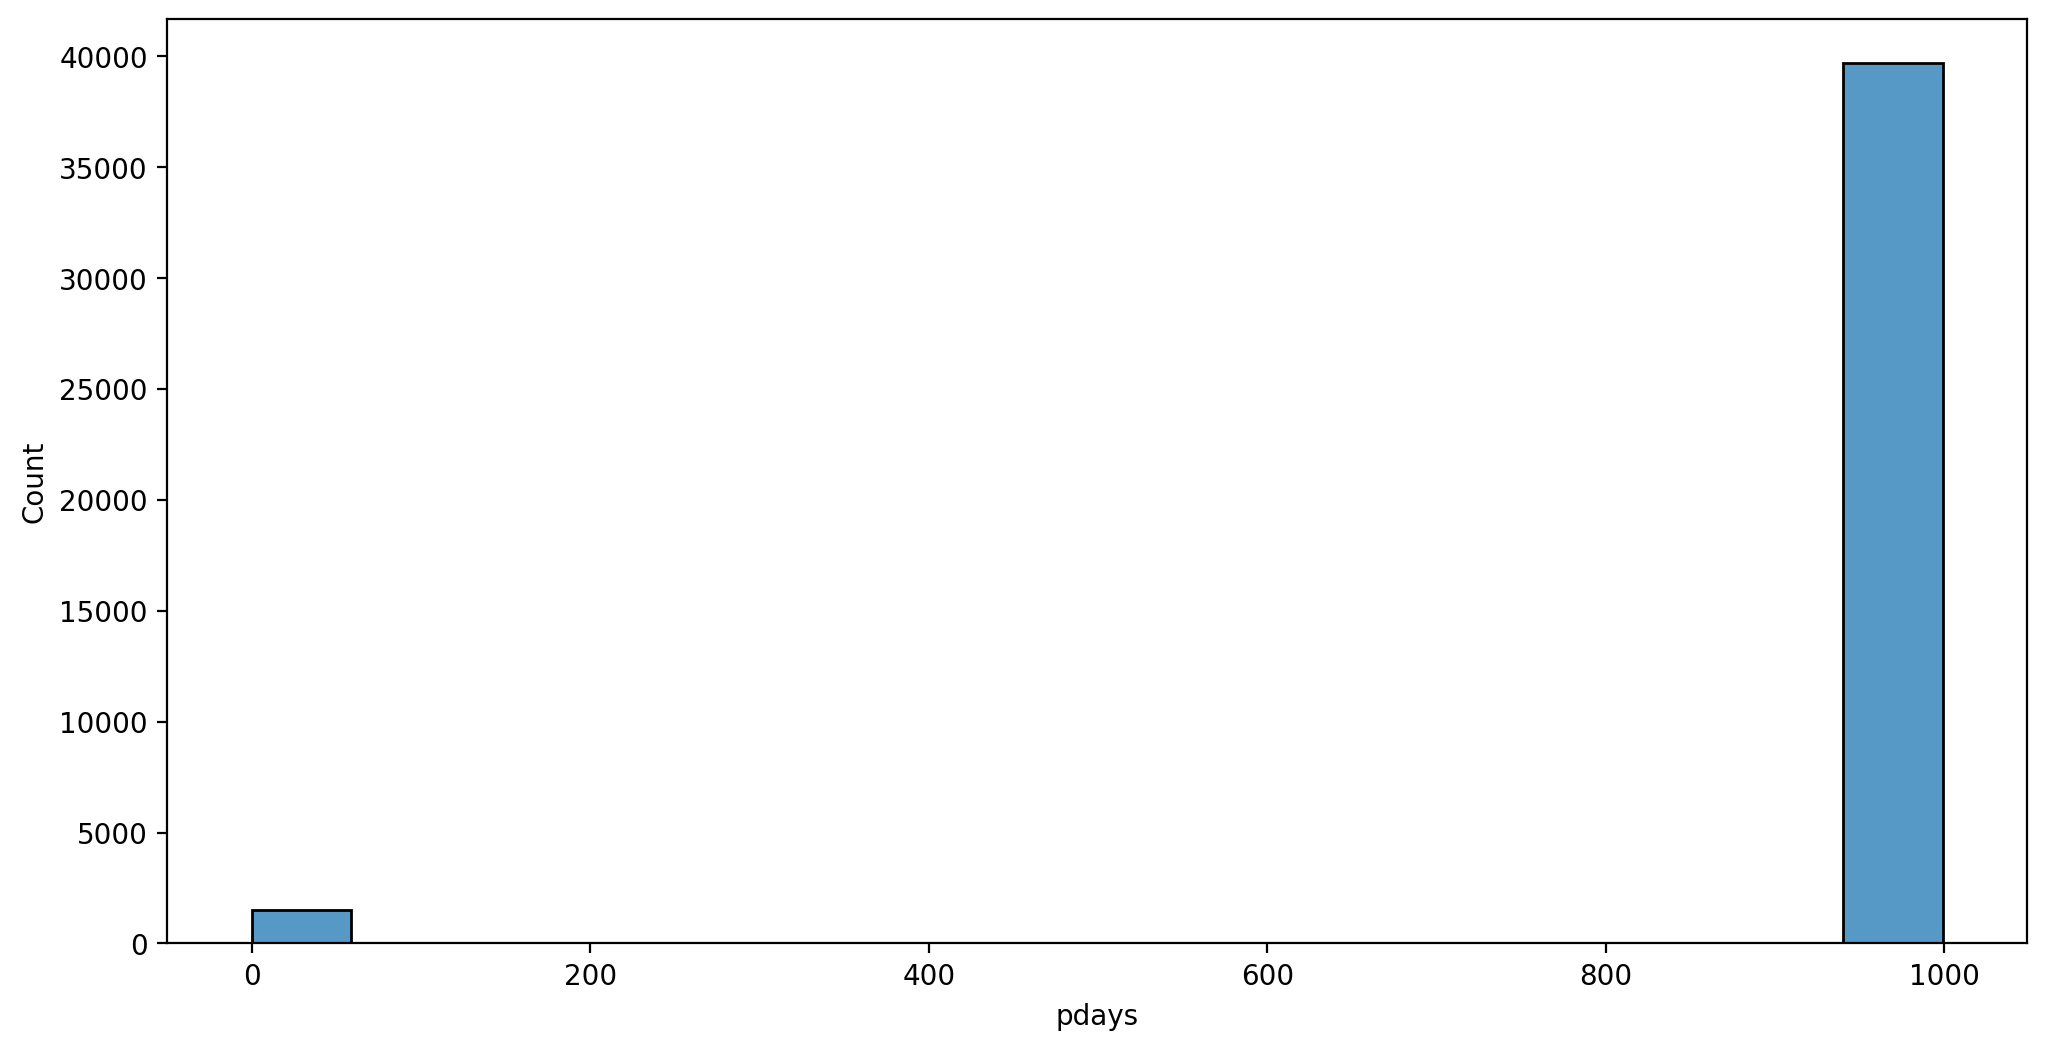

In [26]:
plt.figure(figsize=(12,6),dpi=200)
sns.histplot(data=df,x='pdays')

Based on the data description, 999 means client was not previously contacted.

<Axes: xlabel='pdays', ylabel='Count'>

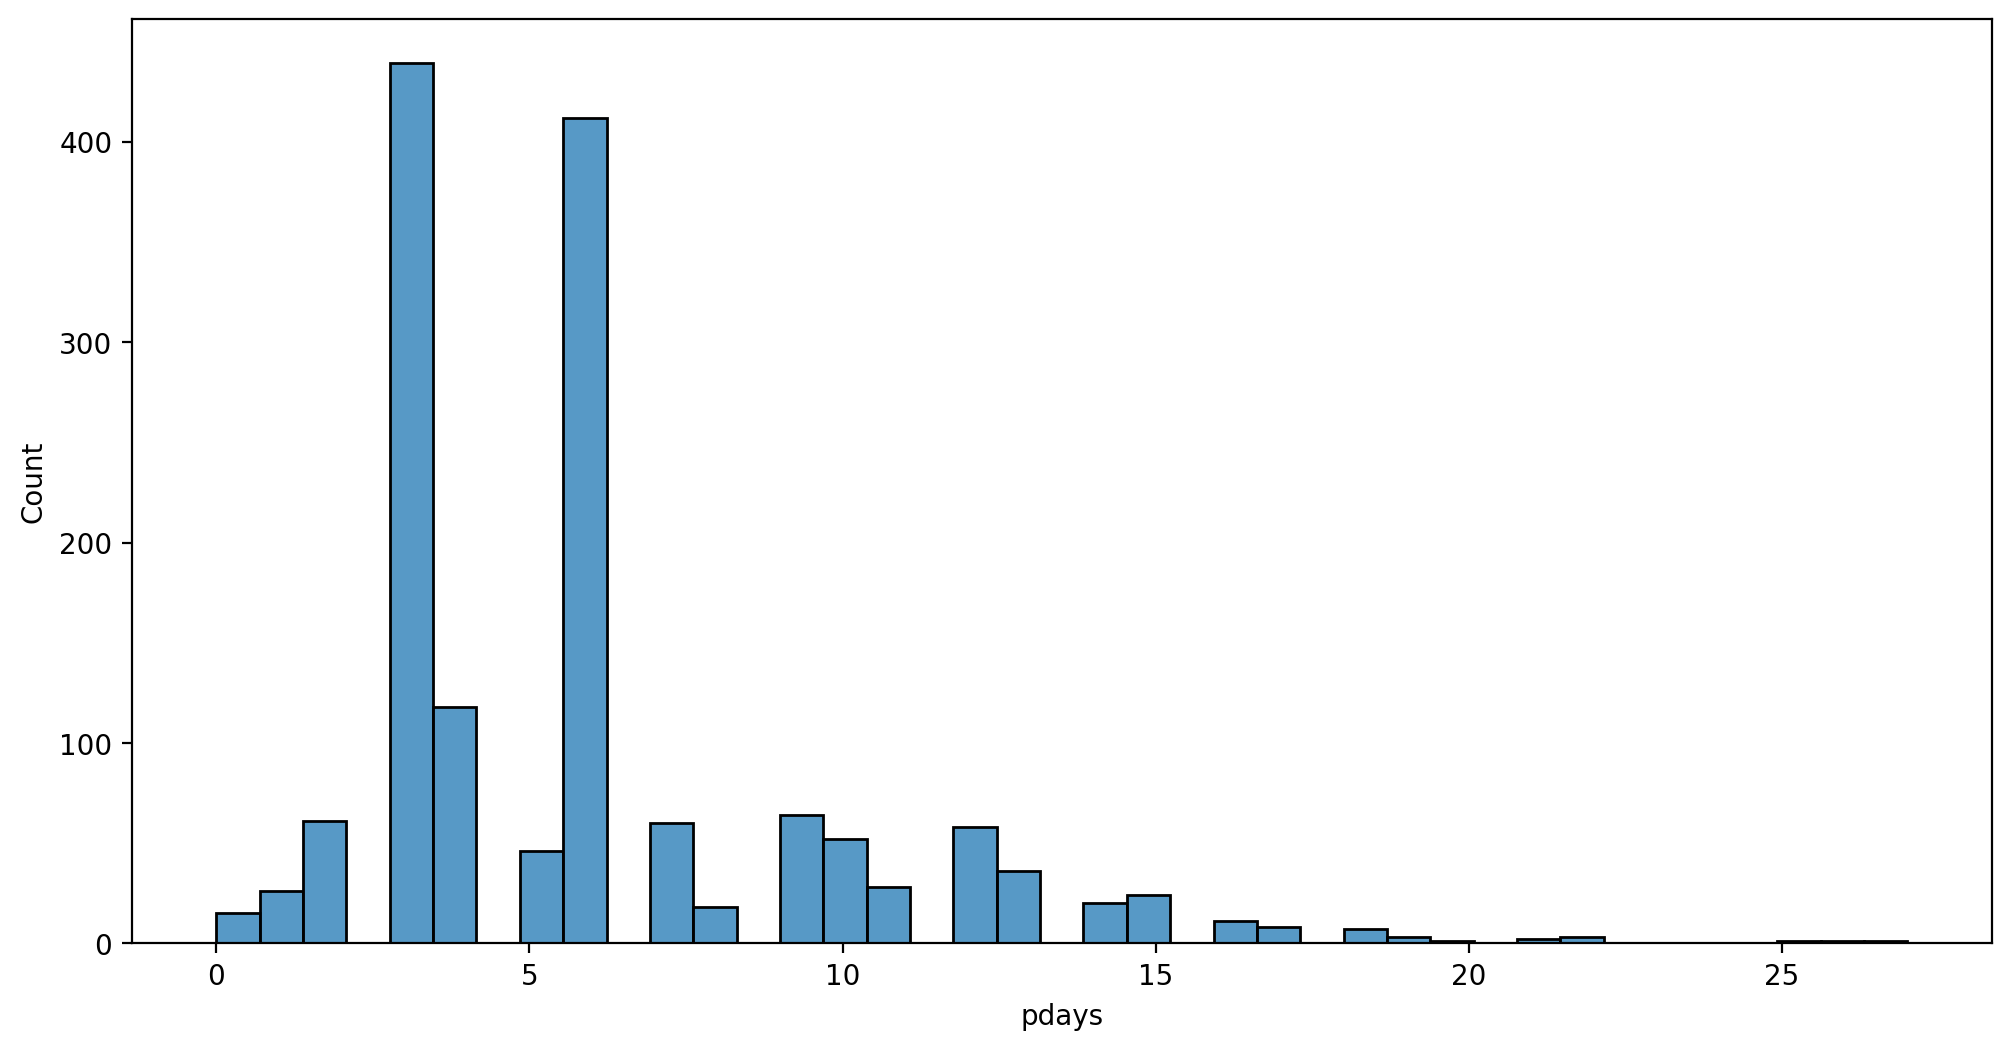

In [27]:
plt.figure(figsize=(12,6),dpi=200)
sns.histplot(data=df[df['pdays']!=999],x='pdays')

**Contact duration - contact with customer made, how long did call last?**

In [28]:
df['contact'].unique()

array(['telephone', 'cellular'], dtype=object)

<Axes: xlabel='duration', ylabel='Count'>

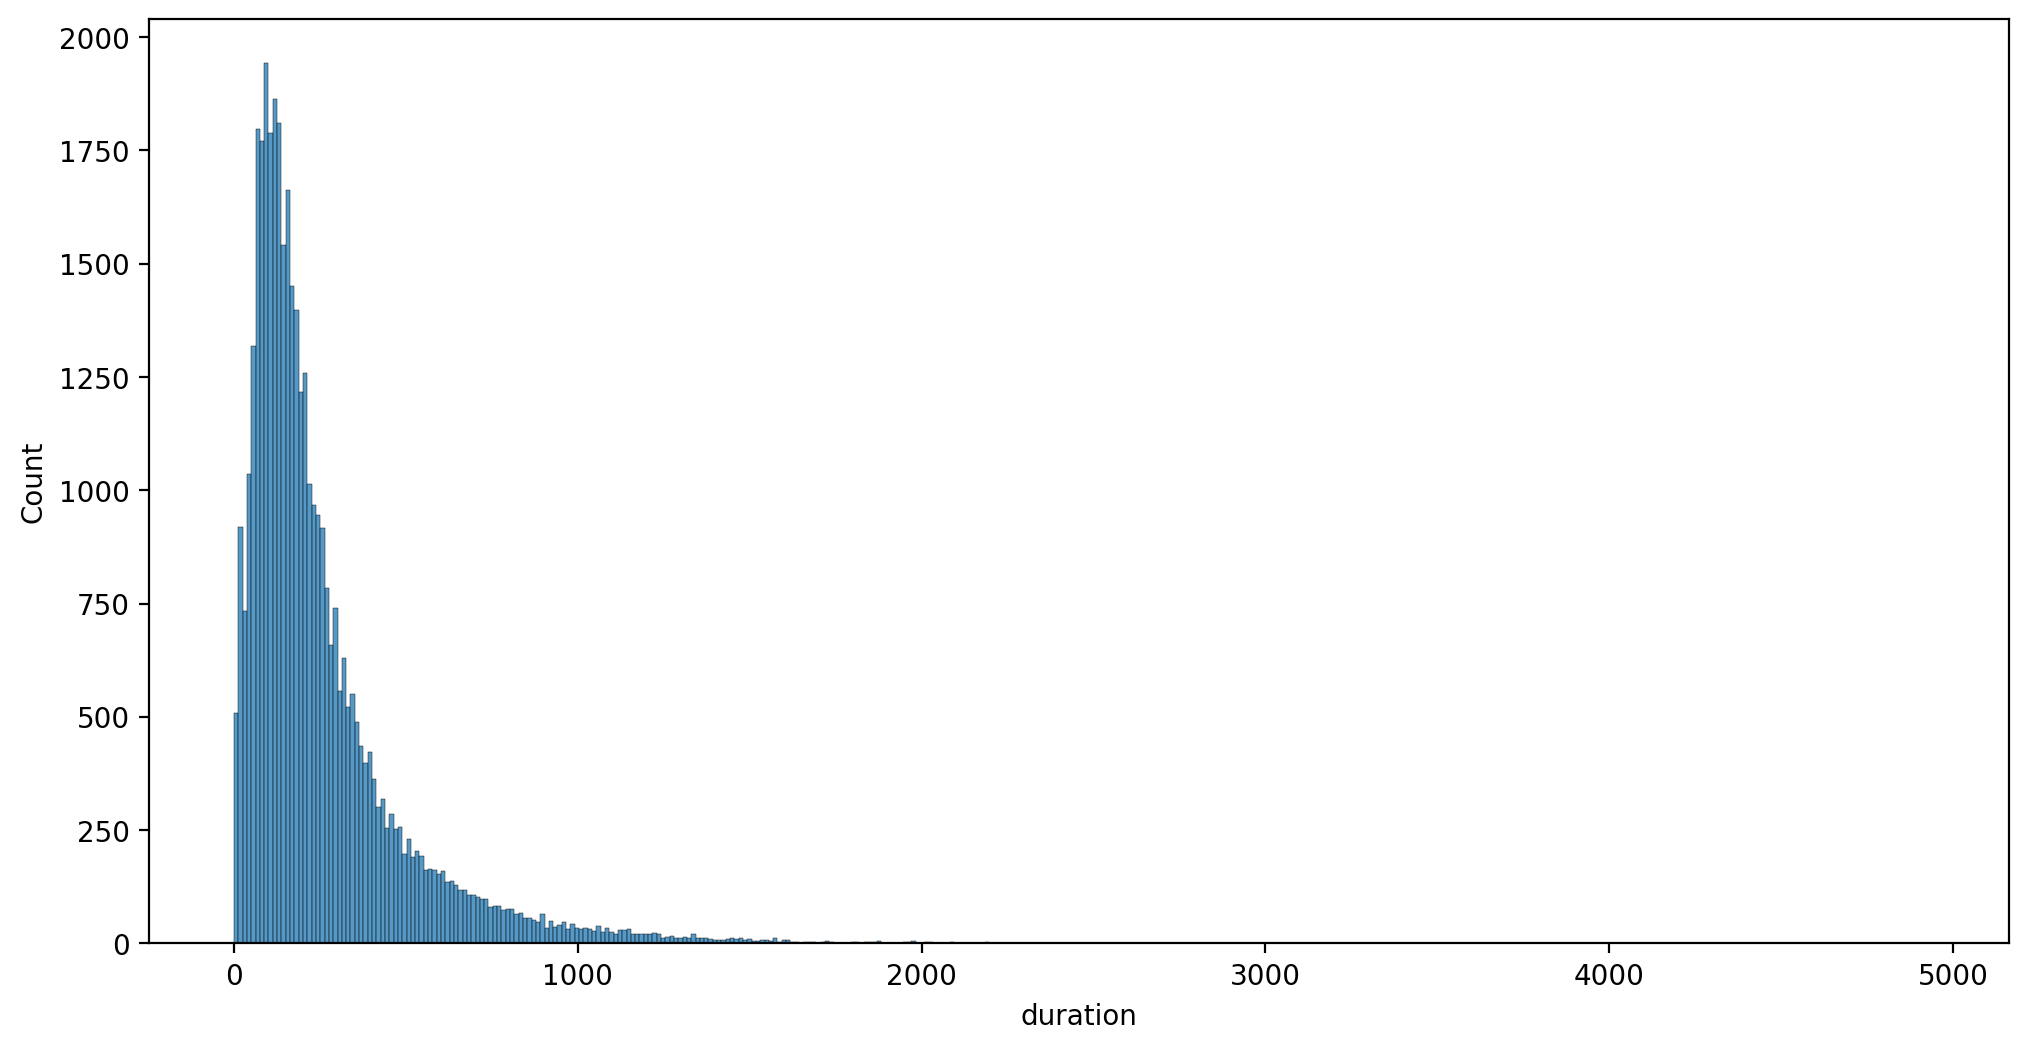

In [29]:
plt.figure(figsize=(12,6),dpi=200)
sns.histplot(data=df,x='duration')

(0.0, 2000.0)

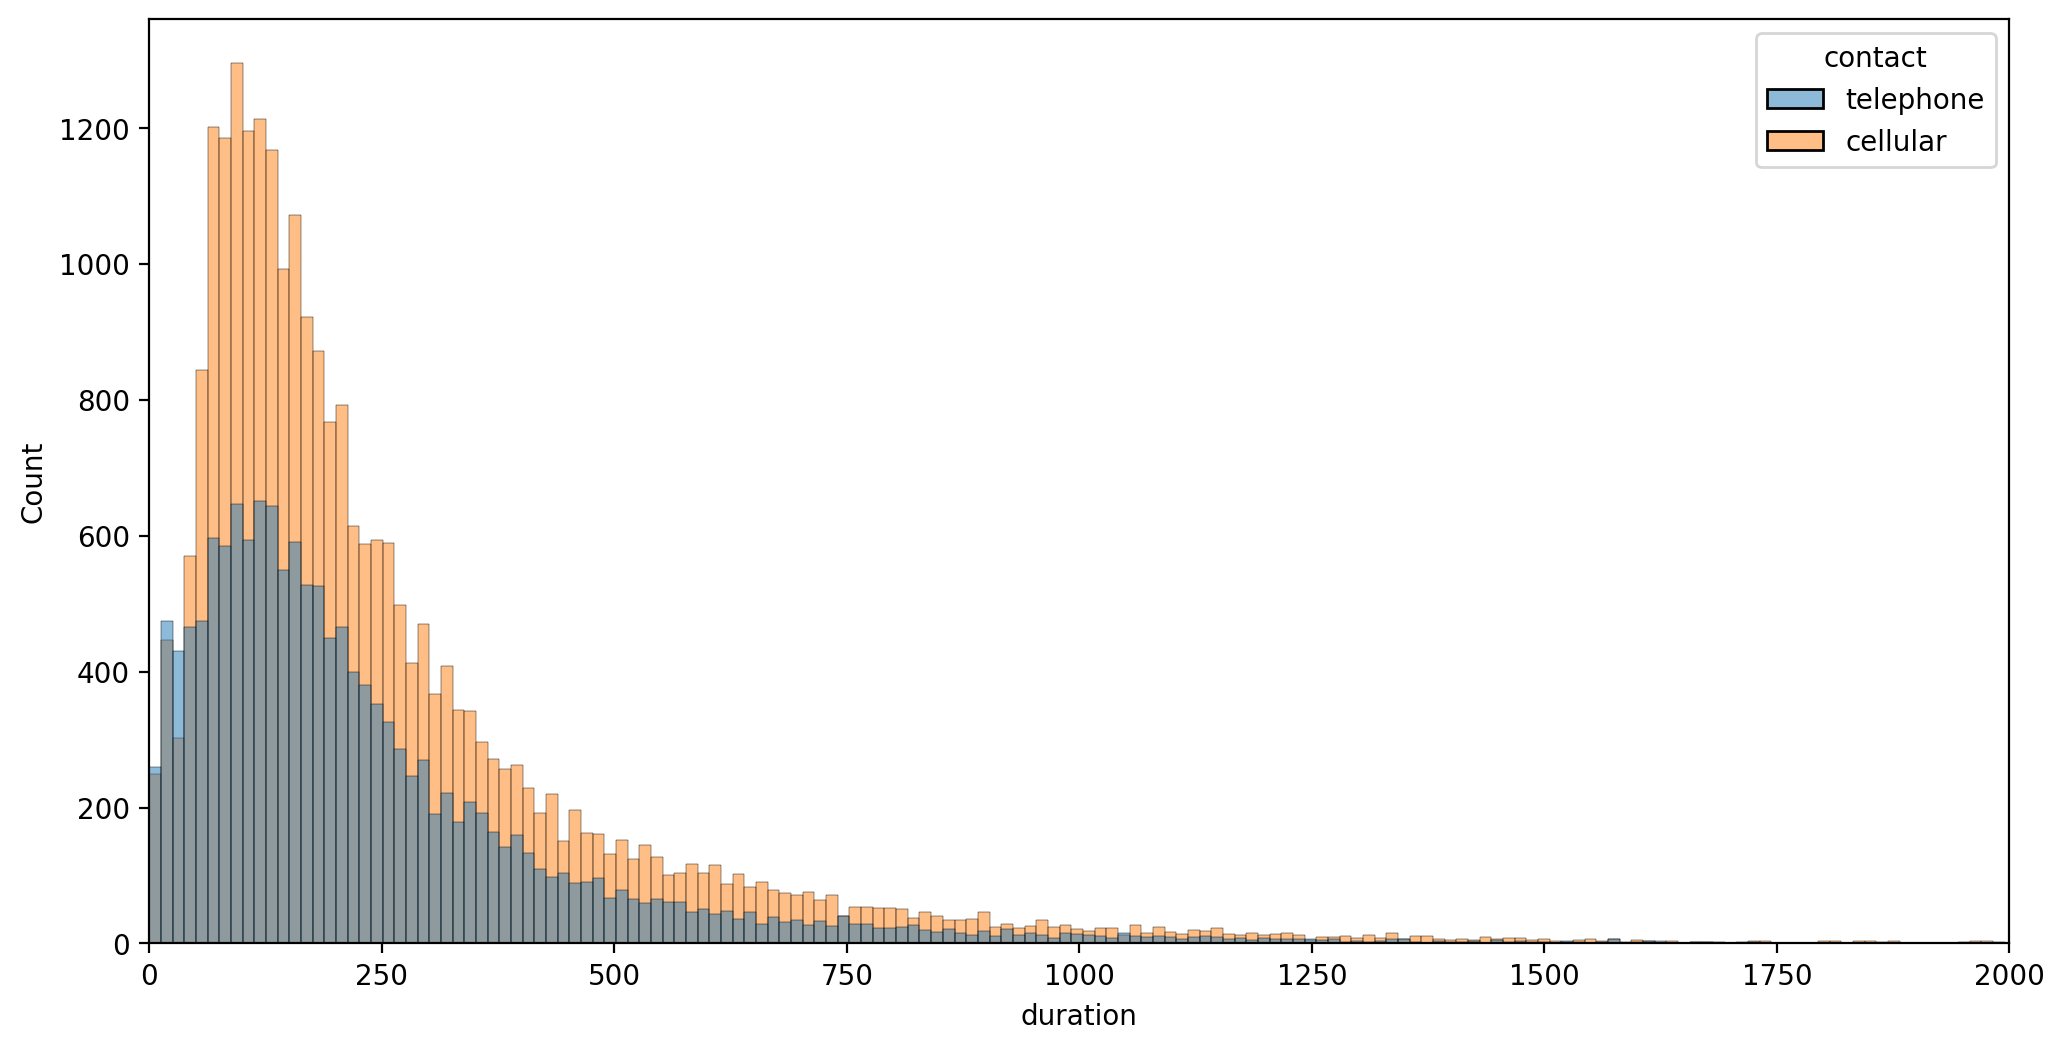

In [30]:
plt.figure(figsize=(12,6),dpi=200)
sns.histplot(data=df,x='duration',hue='contact')
plt.xlim(0,2000)

* 15 - previous: number of contacts performed before this campaign and for this client (numeric)
* 16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success"

<Axes: xlabel='previous', ylabel='count'>

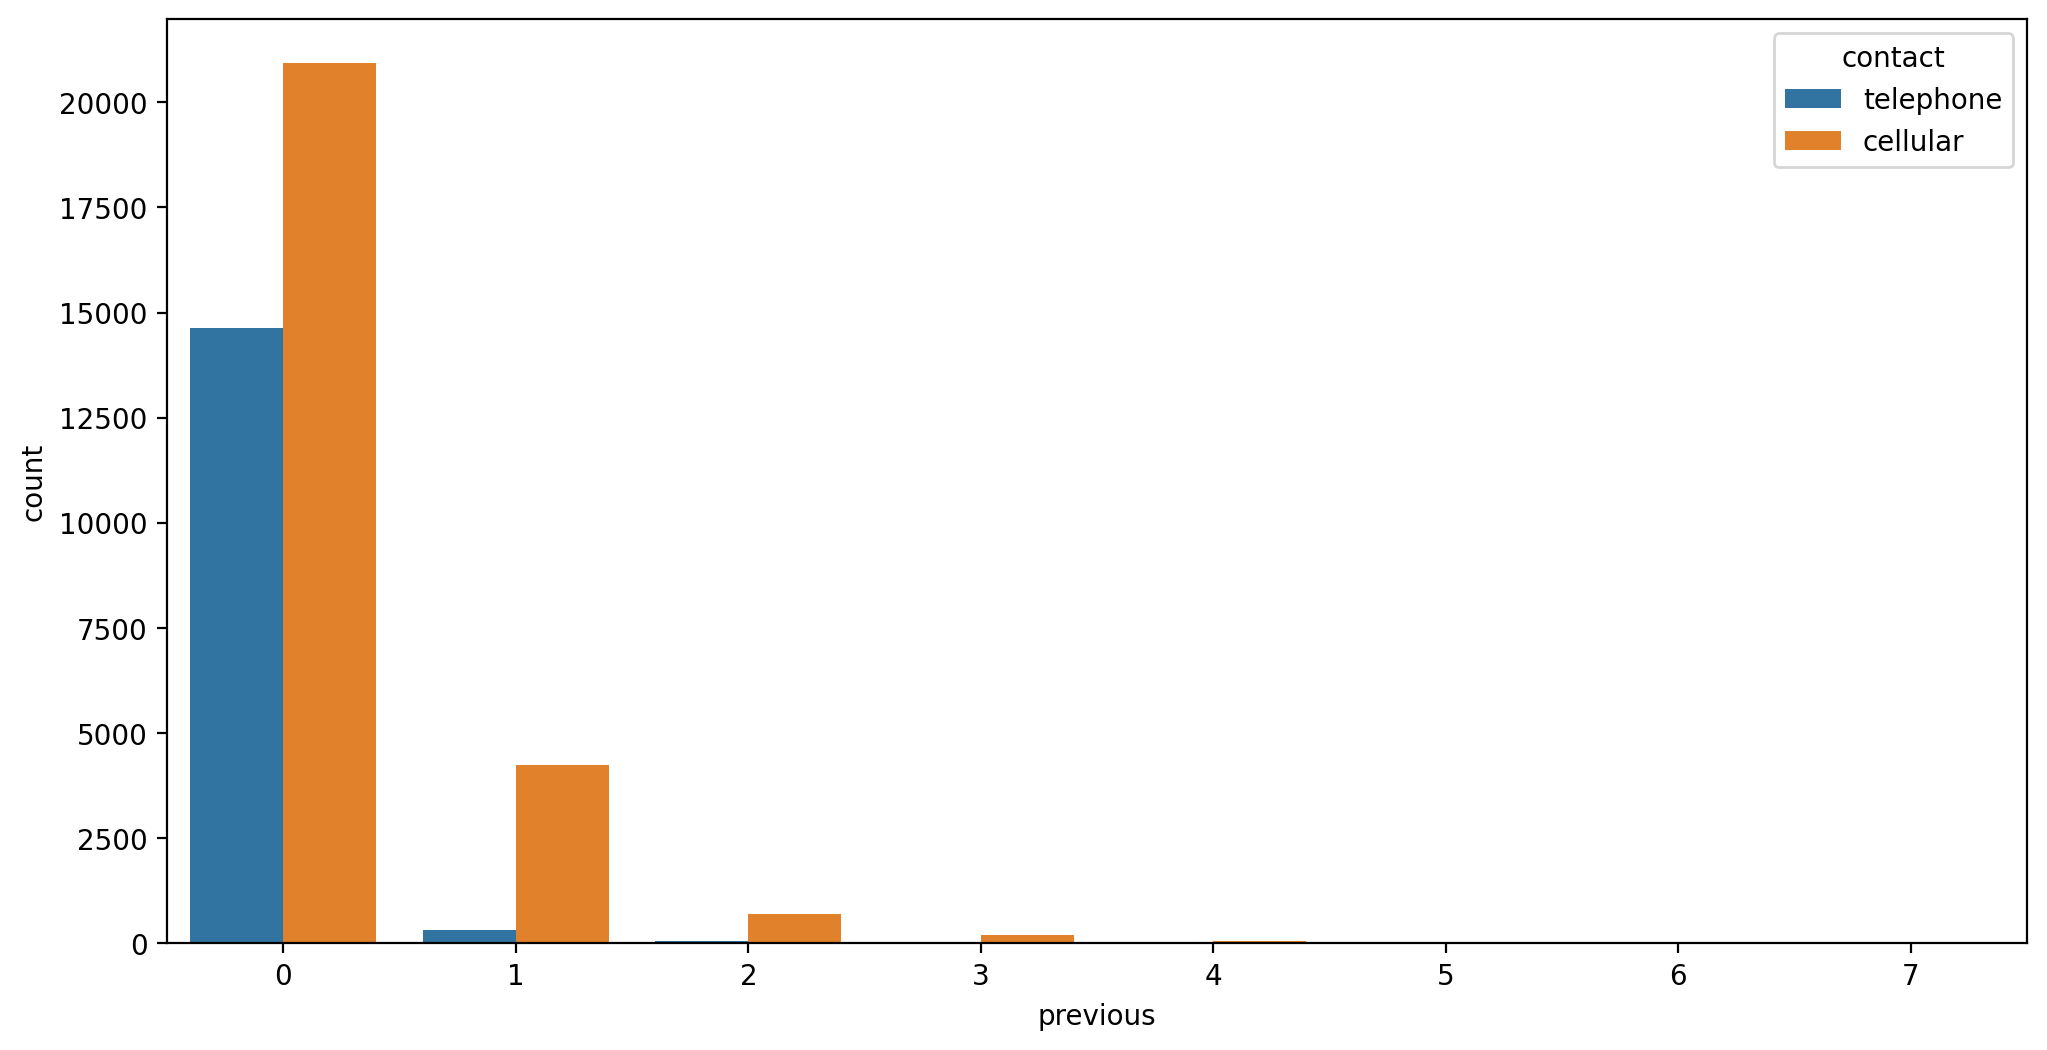

In [33]:
plt.figure(figsize=(12,6),dpi=200)
sns.countplot(data=df,x='previous',hue='contact')

<Axes: xlabel='contact', ylabel='count'>

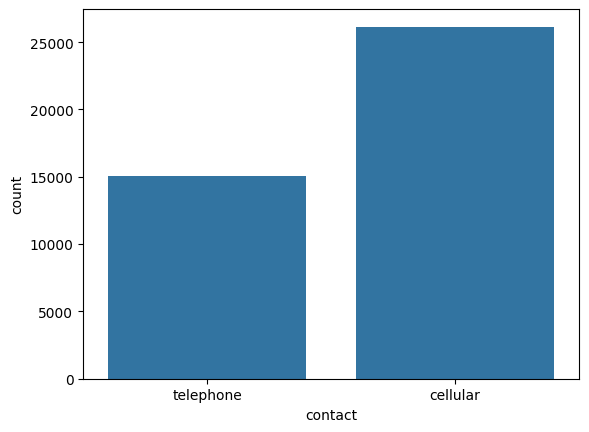

In [34]:
sns.countplot(data=df,x='contact')

In [35]:
# df['previous'].value_counts()
df['previous'].value_counts().sum()-36954
# 36954 vs. 8257

np.int64(4234)

### **Categorical Features**

In [38]:
df['job'].value_counts()

,count
job,
admin.,10422
blue-collar,9254
technician,6743
services,3969
management,2924
retired,1720
entrepreneur,1456
self-employed,1421
housemaid,1060


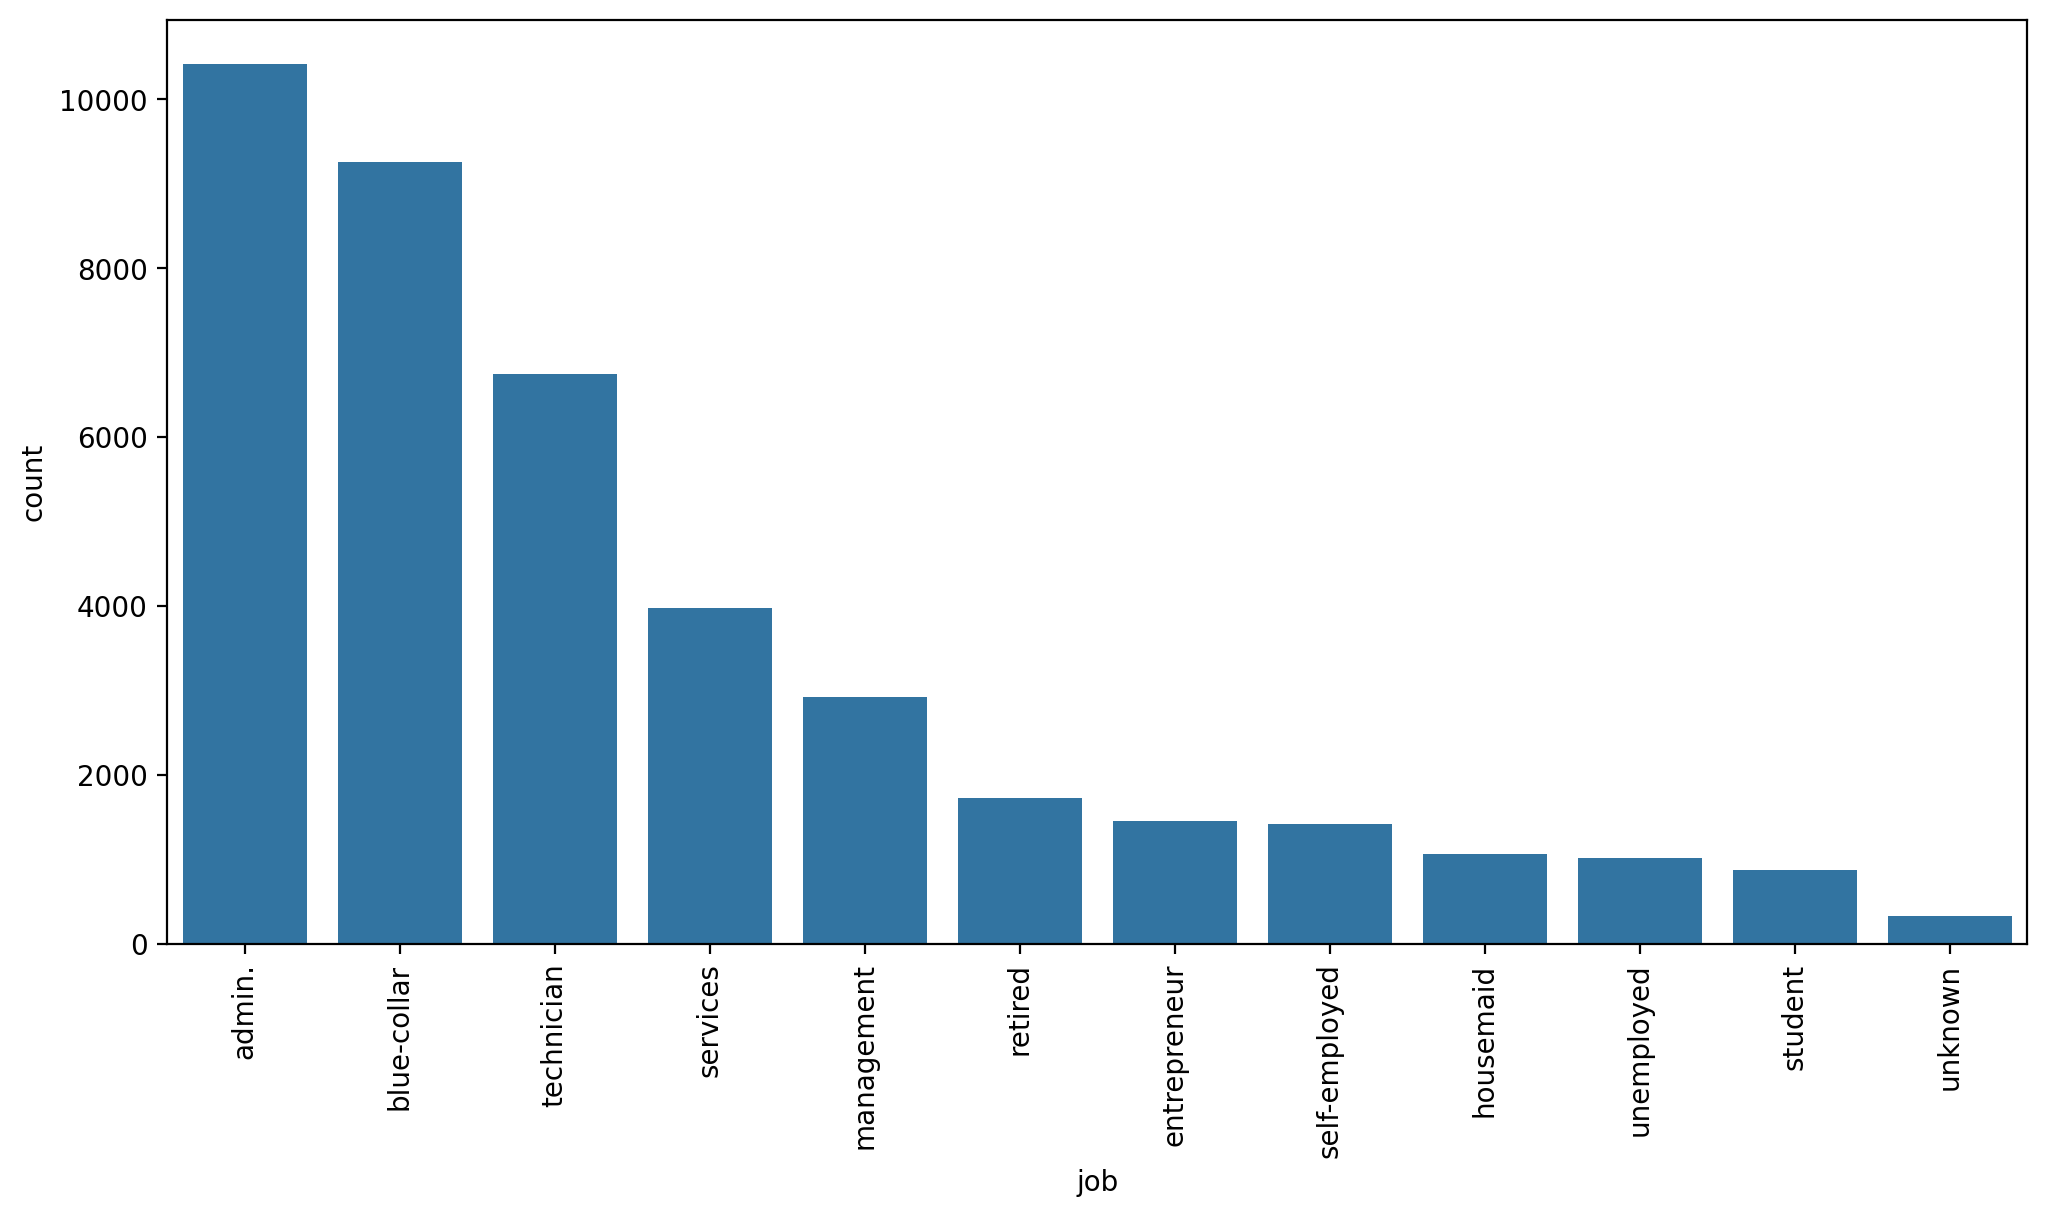

In [37]:
plt.figure(figsize=(12,6),dpi=200)
sns.countplot(data=df,x='job',order=df['job'].value_counts().index)
plt.xticks(rotation=90);

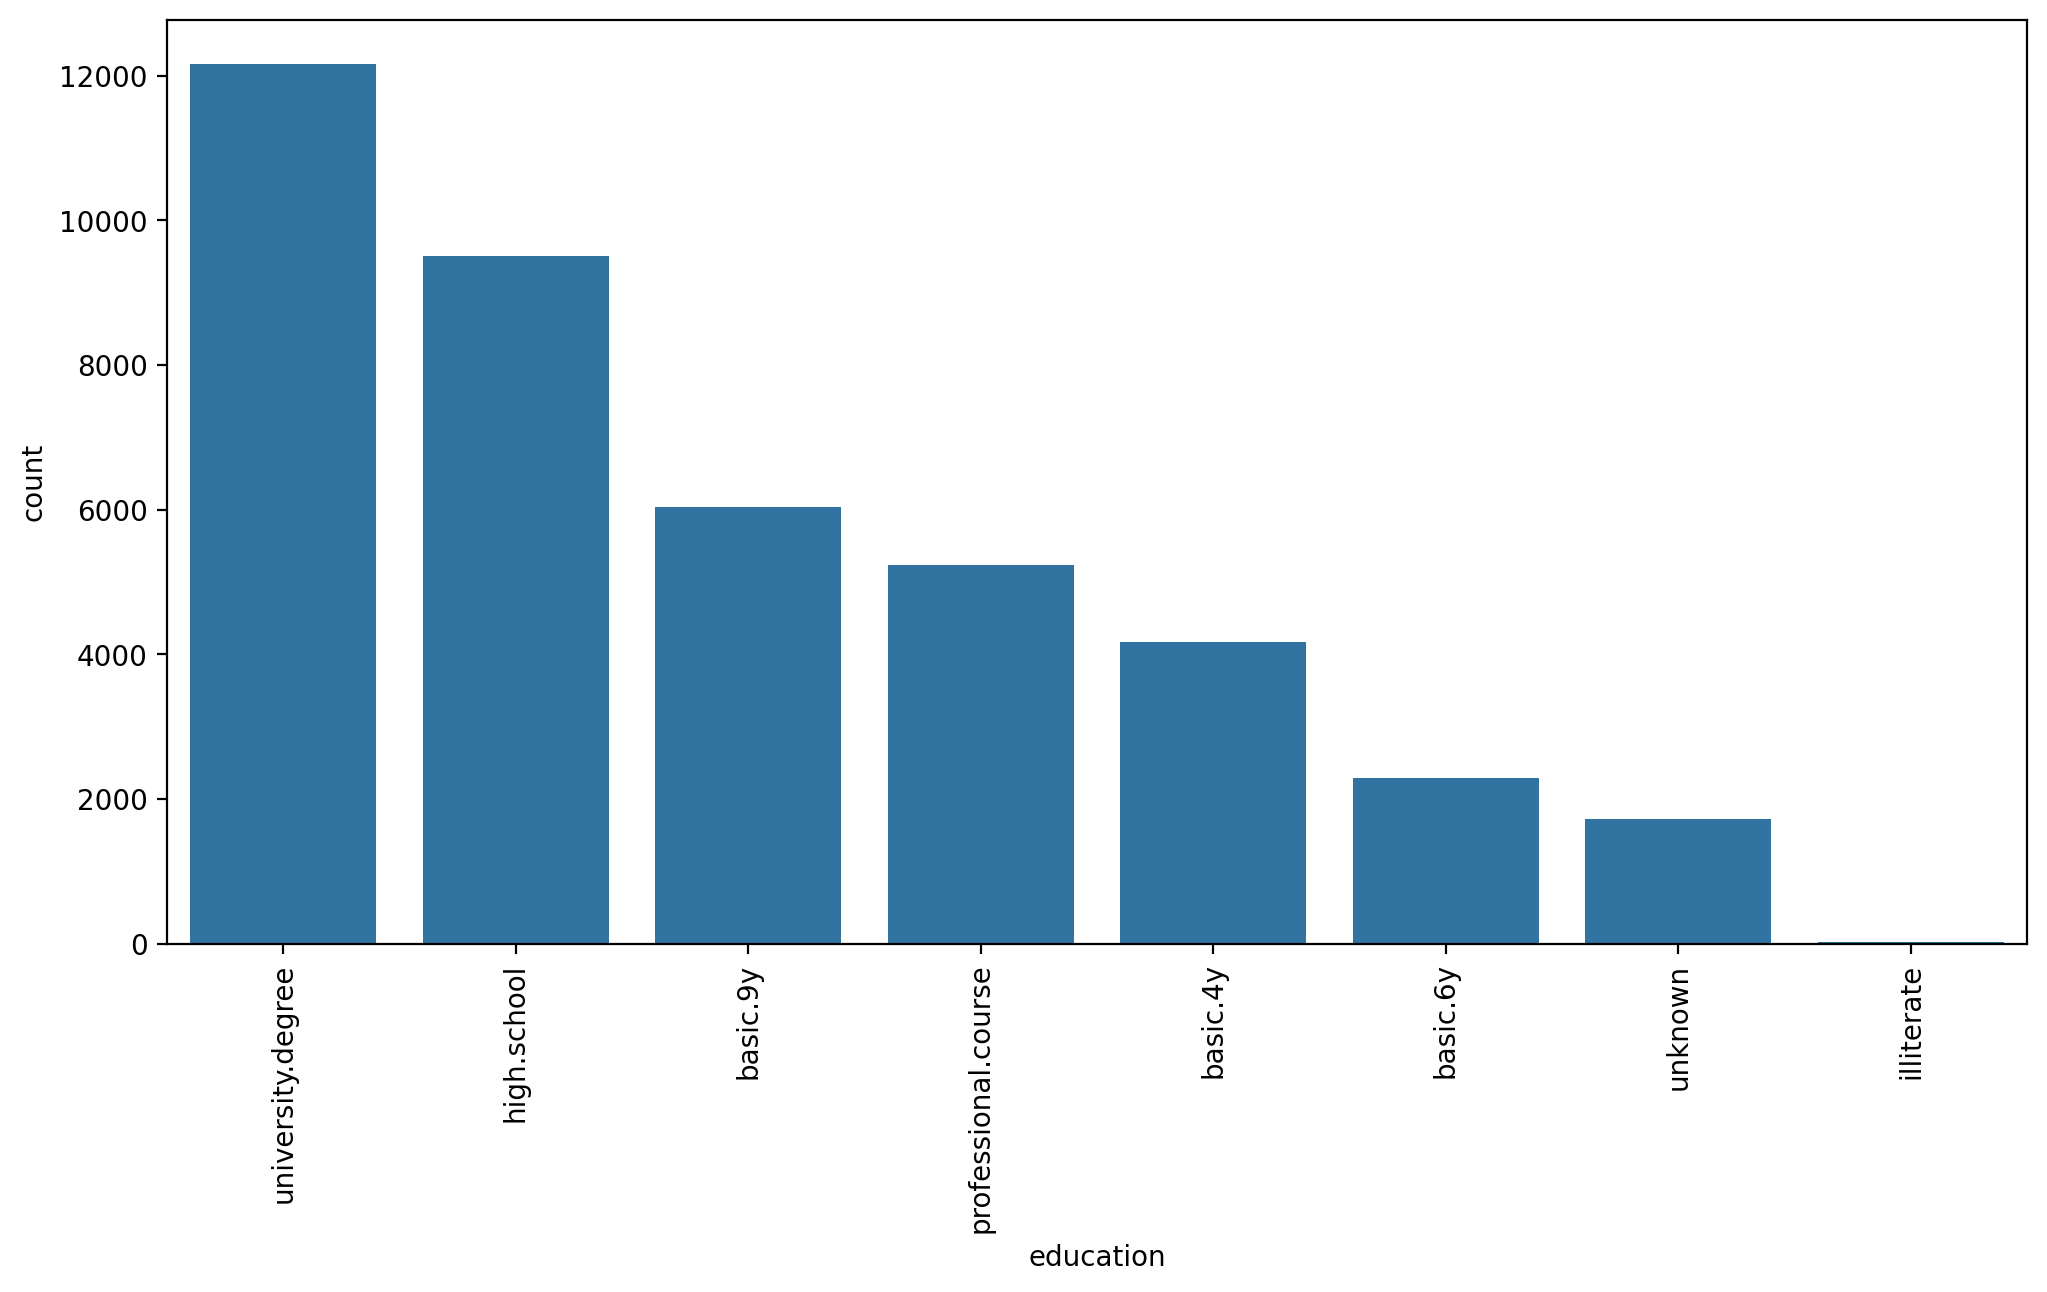

In [40]:
plt.figure(figsize=(12,6),dpi=200)
sns.countplot(data=df,x='education',order=df['education'].value_counts().index)
plt.xticks(rotation=90);

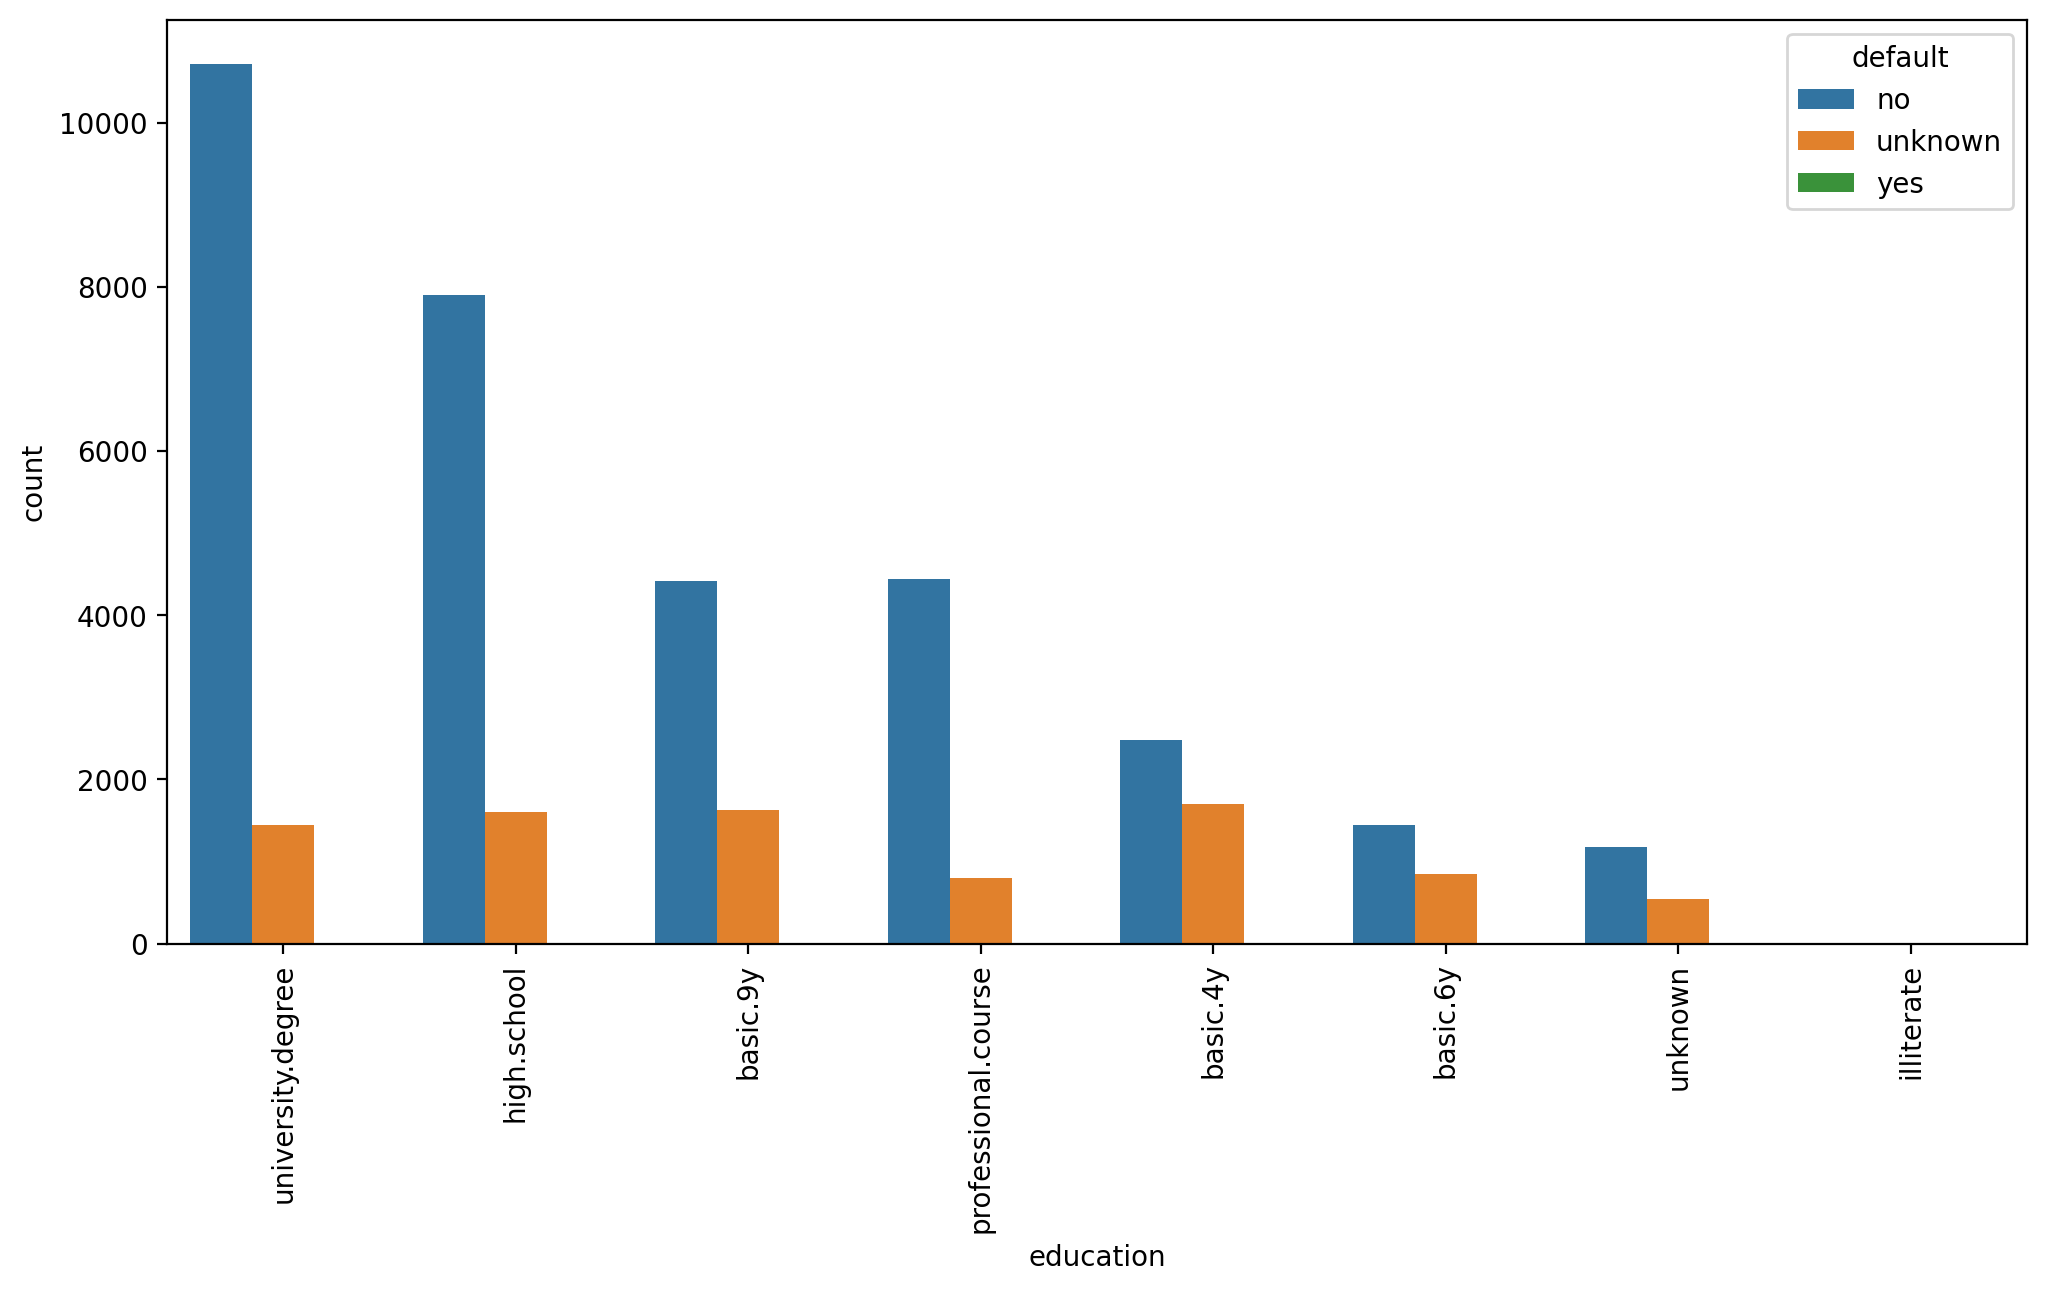

In [41]:
plt.figure(figsize=(12,6),dpi=200)
sns.countplot(data=df,x='education',order=df['education'].value_counts().index,hue='default')
plt.xticks(rotation=90);

<Axes: xlabel='default', ylabel='count'>

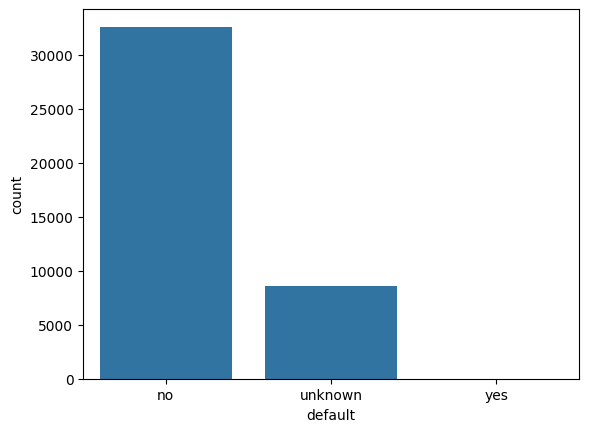

In [42]:
sns.countplot(data=df,x='default')

## **Clustering**

### **Data Preparation**

**UNSUPERVISED LEARNING REMINDER: NO NEED TO TRAIN TEST SPLIT!! NO LABEL TO "TEST" AGAINST!**

We do however need to transform categorical features into numeric ones where it makes sense to do so, as well as scaling the data due to distance being a key factor in clustering.

In [43]:
X = pd.get_dummies(df)

In [44]:
X

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,subscribed_no,subscribed_yes
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,True,False,False,False,False,False,True,False,False,True
41184,46,383,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,True,False,False,False,False,False,True,False,True,False
41185,56,189,2,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,True,False,False,False,False,False,True,False,True,False
41186,44,442,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,True,False,False,False,False,False,True,False,False,True


Since it works based on distance metric we scale

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

### **Creating and Fitting a KMeans Model**

Note of our method choices here:

* fit(X[, y, sample_weight])
    * Compute k-means clustering.

* fit_predict(X[, y, sample_weight])
    * Compute cluster centers and predict cluster index for each sample.

* fit_transform(X[, y, sample_weight])
    * Compute clustering and transform X to cluster-distance space.

* predict(X[, sample_weight])
    * Predict the closest cluster each sample in X belongs to.

In [47]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2)

Let's choose n_clusters=2, it make sense for marketing, people we want to market and do not want!

In [49]:
help(KMeans)

Help on class KMeans in module sklearn.cluster._kmeans:

class KMeans(_BaseKMeans)
 |  KMeans(n_clusters=8, *, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='lloyd')
 |
 |  K-Means clustering.
 |
 |  Read more in the :ref:`User Guide <k_means>`.
 |
 |  Parameters
 |  ----------
 |
 |  n_clusters : int, default=8
 |      The number of clusters to form as well as the number of
 |      centroids to generate.
 |
 |      For an example of how to choose an optimal value for `n_clusters` refer to
 |      :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.
 |
 |  init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
 |      Method for initialization:
 |
 |      * 'k-means++' : selects initial cluster centroids using sampling             based on an empirical probability distribution of the points'             contribution to the overall ine

- `model.fit(X)`: This method is used to train the clustering model. For K-Means, `fit(X)` will calculate the optimal cluster centers (centroids) based on the input data X. After fit() is called, the model object will have learned the clusters, but it doesn't return the cluster assignments or transformations of the data.

- `model.fit_predict(X)`: This method combines the training and prediction steps. It first fits the model to the data X (i.e., it determines the cluster centroids) and then immediately predicts the cluster label for each sample in X. The result is an array containing the cluster assignment for each data point. This is what was used in the notebook (cluster_labels = model.fit_predict(scaled_X)), giving us the 0 or 1 labels for each customer.

- `model.fit_transform(X)`: This method also combines fitting and a transformation. It fits the model to the data X and then transforms X into a new representation. For K-Means, `transform()` typically calculates the distance of each sample to each cluster centroid. So, `fit_transform(X)` would return an array where each row represents a data point, and each column represents the distance to a specific cluster center.

In summary, for K-Means:

- `fit()`: Learns the cluster centers.
- `fit_predict()`: Learns the centers AND assigns each data point to a cluster.
- `fit_transform()`: Learns the centers AND provides the distance of each data point to each cluster center.

In [53]:
cluster_labels = model.fit_predict(scaled_X)

In [54]:
# IMPORTANT NOTE: YOUR 0s and 1s may be opposite of ours,
# makes sense, the number values are not significant!
cluster_labels

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [55]:
len(scaled_X)

41188

In [60]:
X['Cluster'] = cluster_labels
X

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,subscribed_no,subscribed_yes,Cluster
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,False,False,False,False,False,True,False,False,True,1
41184,46,383,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,False,False,False,False,False,True,False,True,False,1
41185,56,189,2,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,False,False,False,False,False,True,False,True,False,1
41186,44,442,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,False,False,False,False,False,True,False,False,True,1


<Axes: >

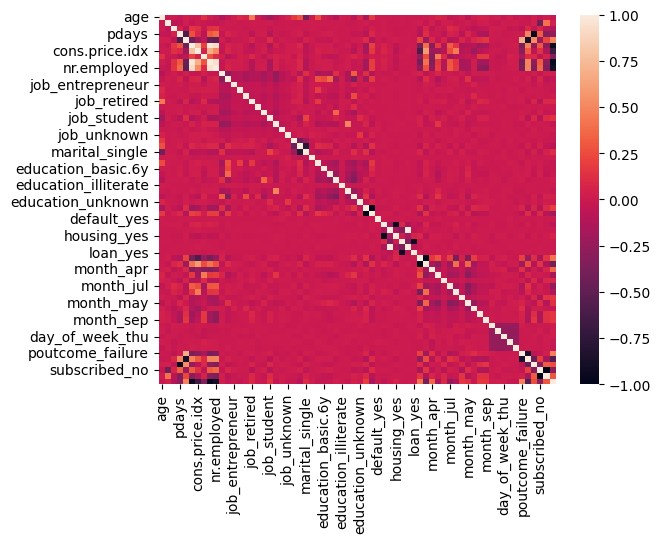

In [57]:
sns.heatmap(X.corr())

In [58]:
X.corr()['Cluster']

,Cluster
age,-0.019659
duration,0.040051
campaign,-0.129101
pdays,-0.267686
previous,0.478442
...,...
poutcome_nonexistent,-0.544348
poutcome_success,0.254379
subscribed_no,-0.294748
subscribed_yes,0.294748


In [63]:
X.corr()['Cluster'].iloc[:-1].sort_values()

,Cluster
euribor3m,-0.959267
emp.var.rate,-0.932603
nr.employed,-0.886120
cons.price.idx,-0.679394
poutcome_nonexistent,-0.544348
...,...
subscribed_yes,0.294748
month_apr,0.357904
contact_cellular,0.410508
poutcome_failure,0.464271


<Axes: >

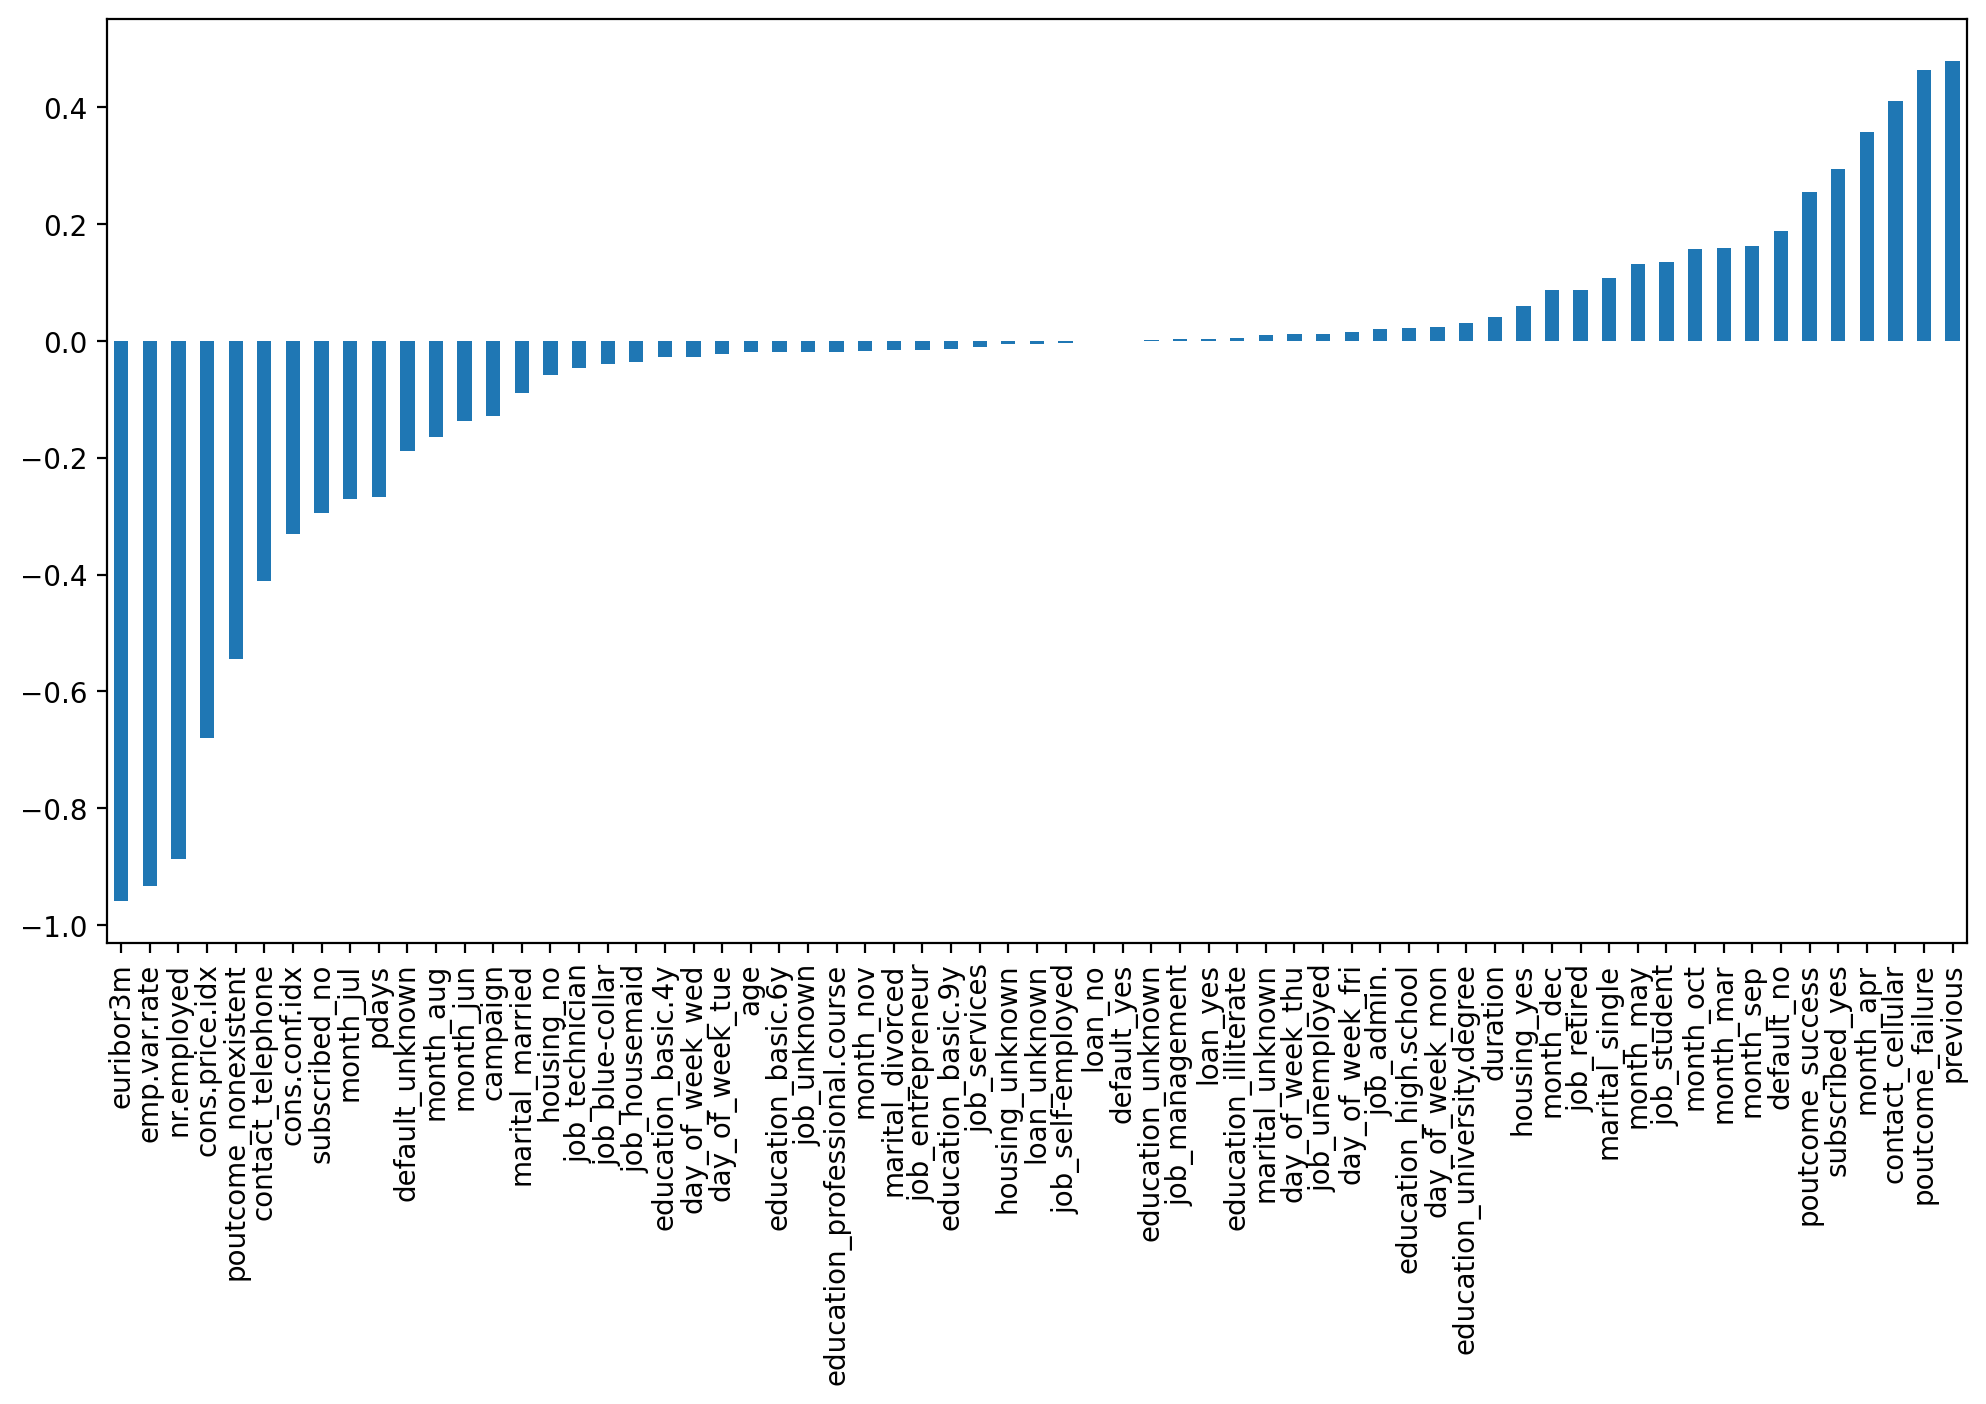

In [59]:
plt.figure(figsize=(12,6),dpi=200)
X.corr()['Cluster'].iloc[:-1].sort_values().plot(kind='bar')

## **Choosing K Value**


- **Elbow Method:**

    Draw a graph showing the some sort of error or accuracy metric for different k values. As k increases the error usually drops at first. But after a certain point error stops decreasing quickly. The point where the curve changes direction and looks like an "elbow" is usually the best choice for k.


- **Metric Calculation:**

    For each k, the Within-Cluster Sum of Squares (WCSS) is calculated.

    This is the sum of the squared distances between each data point and its assigned cluster centroid.

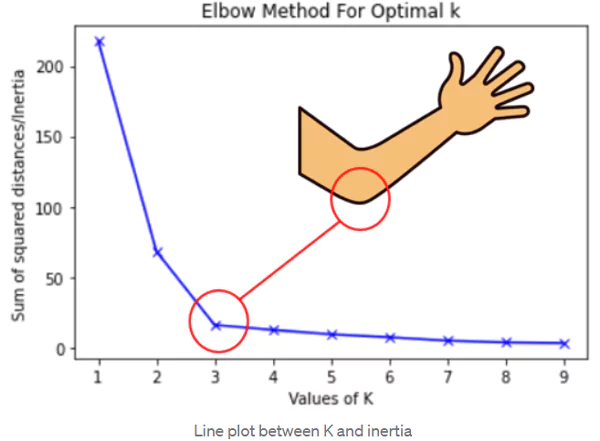

In [71]:
ssd = []

for k in range(2,10):

    model = KMeans(n_clusters=k)


    model.fit(scaled_X)

    #Sum of squared distances of samples to their closest cluster center.
    ssd.append(model.inertia_)

Text(0, 0.5, ' Sum of Squared Distances')

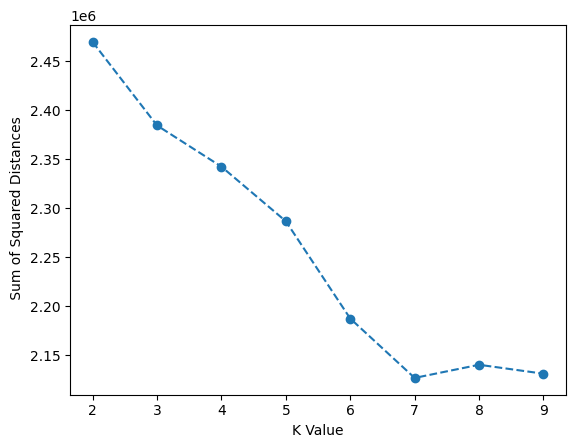

In [72]:
plt.plot(range(2,10),ssd,'o--')
plt.xlabel("K Value")
plt.ylabel(" Sum of Squared Distances")

In [68]:
ssd

[2469792.381034954,
 2370787.0269421116,
 2325315.0464870273,
 2249011.8503124435,
 2251043.4090516046,
 2144944.7628060915,
 2171523.9175130357,
 2003921.6348184166]

In [69]:
# Change in SSD from previous K value!
pd.Series(ssd).diff()

,0
0,NaN
1,-99005.354093
2,-45471.980455
3,-76303.196175
4,2031.558739
5,-106098.646246
6,26579.154707
7,-167602.282695


<Axes: >

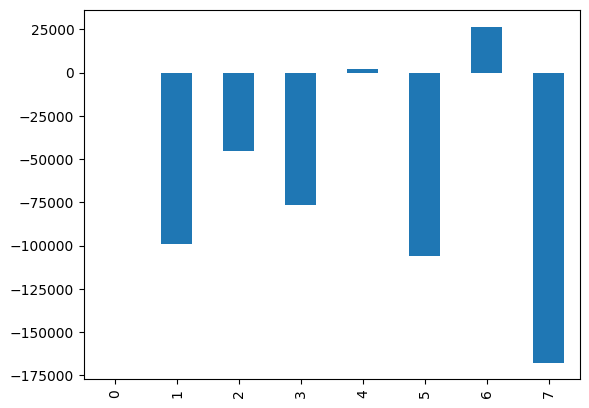

In [70]:
pd.Series(ssd).diff().plot(kind='bar')